In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 11,
    "axes.titlesize": 13,
})

np.random.seed(42)
torch.manual_seed(42)

Ready.


---
# 1) Regularization

Regularization encompasses any technique that constrains or penalizes model complexity to **reduce overfitting** — the gap between training performance and generalization performance.

**Why**

A model's generalization error decomposes as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Term | Meaning | Effect of more capacity |
|------|---------|------------------------|
| **Bias** | Systematic error from underfitting | Decreases |
| **Variance** | Sensitivity to training set fluctuations | Increases |
| **Noise** | Inherent randomness in data | Unchanged |

Deep networks have enormous capacity → low bias, high variance. Regularization trades a small increase in bias for a large decrease in variance.


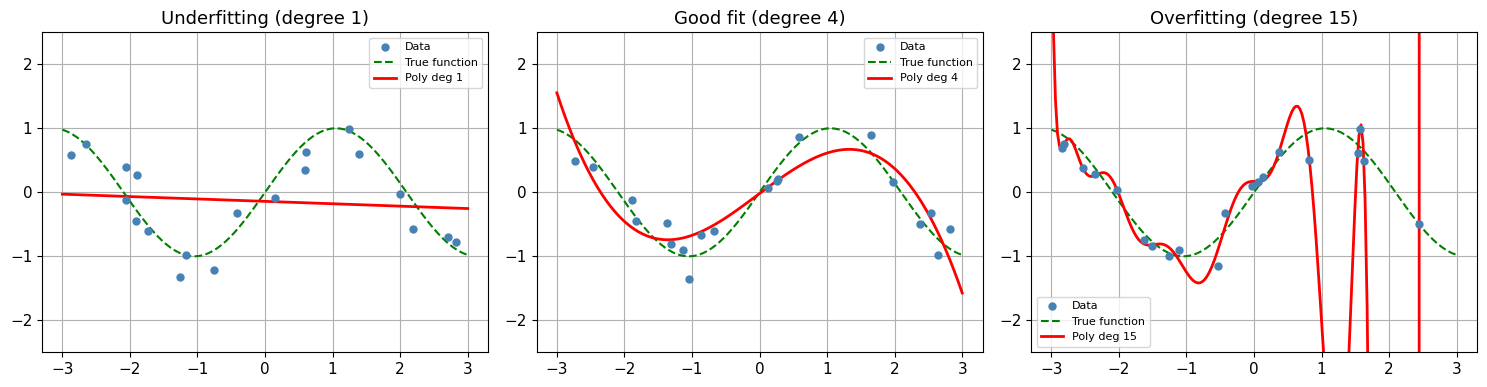

In [ ]:
# Demonstrate bias-variance tradeoff with polynomial regression
true_fn = lambda x: np.sin(1.5 * x)
num_samples = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 4, 15]
titles = ["Underfitting (degree 1)", "Good fit (degree 4)", "Overfitting (degree 15)"]
x_plot = np.linspace(-3, 3, 200)

for ax, deg, title in zip(axes, degrees, titles):
    x_train = np.random.uniform(-3, 3, num_samples)
    y_train = true_fn(x_train) + np.random.randn(num_samples) * 0.3

    coeffs = np.polyfit(x_train, y_train, deg)
    y_pred = np.polyval(coeffs, x_plot)

    ax.scatter(x_train, y_train, c="steelblue", s=25, zorder=5, label="Data")
    ax.plot(x_plot, true_fn(x_plot), "g--", lw=1.5, label="True function")
    ax.plot(x_plot, y_pred, "r-", lw=2, label=f"Poly deg {deg}")
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 1.1 L2 Regularization (Weight Decay)

In [ ]:
class L2RegularizedNetwork:
    """Simple fully-connected network with L2 regularization."""

    def __init__(self, layer_dims, lambd=0.0):
        self.lambd = lambd
        self.num_layers = len(layer_dims) - 1
        self.params = {}
        self.cache = {}

        for l in range(1, self.num_layers + 1):
            # He initialization
            # (hidden_dim, input_dim)
            self.params[f"W{l}"] = np.random.randn(
                layer_dims[l], layer_dims[l - 1]
            ) * np.sqrt(2.0 / layer_dims[l - 1])
            # (hidden_dim, 1)
            self.params[f"b{l}"] = np.zeros((layer_dims[l], 1))

    def _relu(self, Z):
        return np.maximum(0, Z)

    def _sigmoid(self, Z):
        return 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))

    def forward(self, X):
        # (input_dim, batch_num)
        A = X
        self.cache["A0"] = A

        for l in range(1, self.num_layers):
            W = self.params[f"W{l}"]
            b = self.params[f"b{l}"]
            # (hidden_dim, batch_num)
            Z = W @ A + b
            # (hidden_dim, batch_num)
            A = self._relu(Z)
            self.cache[f"Z{l}"] = Z
            self.cache[f"A{l}"] = A

        # Output layer with sigmoid
        W = self.params[f"W{self.num_layers}"]
        b = self.params[f"b{self.num_layers}"]
        # (output_dim, batch_num)
        Z = W @ A + b
        # (output_dim, batch_num)
        A = self._sigmoid(Z)
        self.cache[f"Z{self.num_layers}"] = Z
        self.cache[f"A{self.num_layers}"] = A
        return A

    def compute_cost(self, A_last, Y):
        batch_num = Y.shape[1]

        # Binary cross-entropy
        # scalar
        bce = -np.mean(Y * np.log(A_last + 1e-8) + (1 - Y) * np.log(1 - A_last + 1e-8))

        # L2 penalty: (lambda / 2m) * sum of squared Frobenius norms
        l2_penalty = 0.0
        for l in range(1, self.num_layers + 1):
            l2_penalty += np.sum(self.params[f"W{l}"] ** 2)
        l2_penalty *= self.lambd / (2 * batch_num)

        return bce + l2_penalty

    def backward(self, Y):
        grads = {}
        batch_num = Y.shape[1]
        A_last = self.cache[f"A{self.num_layers}"]

        # Output layer gradient (BCE + sigmoid)
        # (output_dim, batch_num)
        dZ = A_last - Y

        for l in range(self.num_layers, 0, -1):
            A_prev = self.cache[f"A{l - 1}"]

            # (hidden_dim, input_dim) with L2 gradient penalty
            grads[f"dW{l}"] = (1 / batch_num) * (dZ @ A_prev.T) + \
                (self.lambd / batch_num) * self.params[f"W{l}"]
            # (hidden_dim, 1)
            grads[f"db{l}"] = (1 / batch_num) * np.sum(dZ, axis=1, keepdims=True)

            if l > 1:
                # (input_dim, batch_num)
                dA_prev = self.params[f"W{l}"].T @ dZ
                # ReLU derivative
                # (input_dim, batch_num)
                dZ = dA_prev * (self.cache[f"Z{l - 1}"] > 0).astype(float)

        return grads

    def update_params(self, grads, lr):
        for l in range(1, self.num_layers + 1):
            self.params[f"W{l}"] -= lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= lr * grads[f"db{l}"]

    def train(self, X, Y, lr=0.01, epochs=5000, verbose=True):
        costs = []
        for epoch in range(epochs):
            A_last = self.forward(X)
            cost = self.compute_cost(A_last, Y)
            grads = self.backward(Y)
            self.update_params(grads, lr)
            if epoch % 500 == 0:
                costs.append(cost)
                if verbose:
                    print(f"Epoch {epoch:5d} | Cost: {cost:.6f}")
        return costs


print("L2RegularizedNetwork defined.")

L2RegularizedNetwork defined.


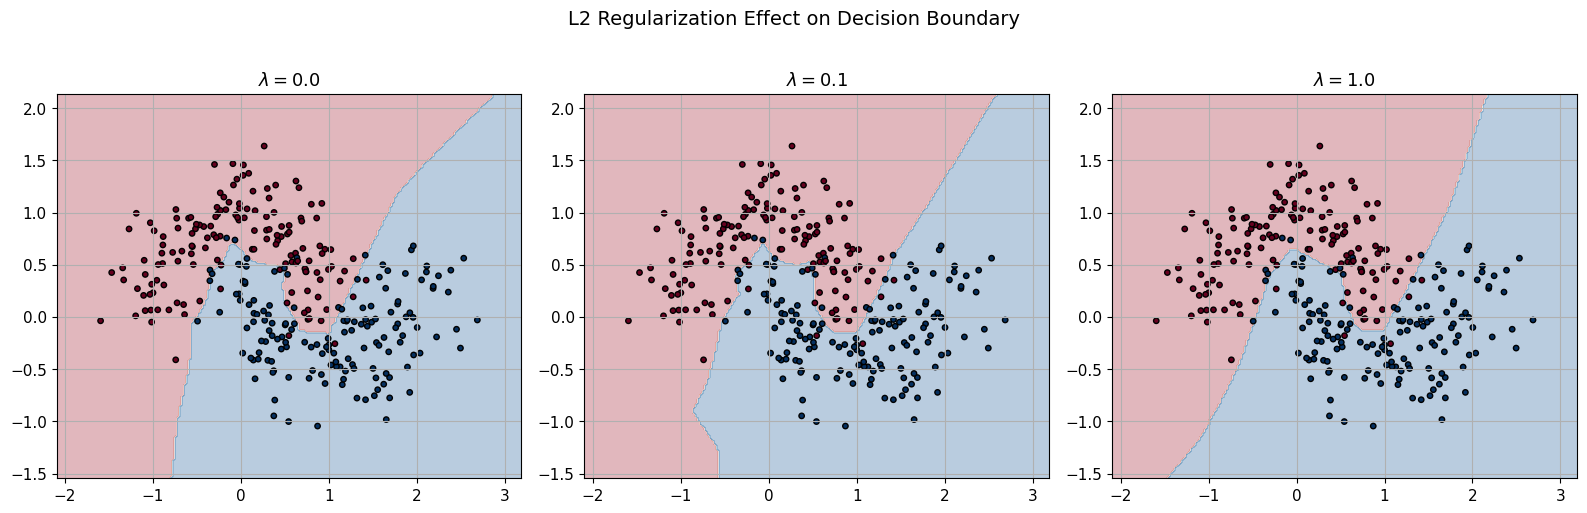

In [ ]:
def plot_decision_boundary(model, X, Y, ax, title):
    """Plot 2D decision boundary for binary classifier."""
    x_min, x_max = X[0].min() - 0.5, X[0].max() + 0.5
    y_min, y_max = X[1].min() - 0.5, X[1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )
    # (2, num_grid_points)
    grid = np.c_[xx.ravel(), yy.ravel()].T
    # (1, num_grid_points)
    preds = model.forward(grid)
    preds = (preds > 0.5).astype(int).reshape(xx.shape)

    ax.contourf(xx, yy, preds, alpha=0.3, cmap="RdBu")
    ax.scatter(X[0], X[1], c=Y.ravel(), cmap="RdBu", edgecolors="k", s=15)
    ax.set_title(title)


# Generate noisy moons dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)
# (2, num_samples)
X_data = X_moons.T
# (1, num_samples)
Y_data = y_moons.reshape(1, -1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lambdas = [0.0, 0.1, 1.0]

for ax, lam in zip(axes, lambdas):
    net = L2RegularizedNetwork([2, 20, 15, 10, 1], lambd=lam)
    net.train(X_data, Y_data, lr=0.05, epochs=6000, verbose=False)
    plot_decision_boundary(net, X_data, Y_data, ax, f"$\\lambda = {lam}$")

plt.suptitle("L2 Regularization Effect on Decision Boundary", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** As $\lambda$ increases, the decision boundary becomes smoother. The network trades off fitting every noisy point (low bias, high variance) for a simpler boundary (slightly higher bias, much lower variance).

## 1.2 Dropout

Dropout (Srivastava et al., 2014) randomly zeros out activations during training.

Each neuron is kept with probability $p$ (the **keep probability**) and dropped with probability $1 - p$.

### 1.2.1 Inverted Dropout Forward Pass

In [ ]:
def inverted_dropout_forward(A, keep_prob, training=True):
    """Apply inverted dropout to activations.

    Returns (masked_activation, dropout_mask).
    """
    if not training or keep_prob == 1.0:
        return A, np.ones_like(A)

    # Binary mask: 1 = keep, 0 = drop
    # (same shape as A)
    D = (np.random.rand(*A.shape) < keep_prob).astype(float)

    # Apply mask and scale by 1/p
    # (same shape as A)
    # dividing by keep_prob to compensate the remaining neurons
    A_dropped = (A * D) / keep_prob

    return A_dropped, D

# Demo: effect of dropout on a random activation matrix
np.random.seed(0)
# (4, 6)
A_demo = np.random.randn(4, 6)
A_drop, mask = inverted_dropout_forward(A_demo, keep_prob=0.5)

print("Original activations:")
print(np.round(A_demo, 2))
print("\nDropout mask (keep_prob=0.5):")
print(mask.astype(int))
print("\nAfter inverted dropout:")
print(np.round(A_drop, 2))
print(f"\nExpected value check — Mean before: {A_demo.mean():.4f}, after: {A_drop.mean():.4f}")

Original activations:
[[ 1.76  0.4   0.98  2.24  1.87 -0.98]
 [ 0.95 -0.15 -0.1   0.41  0.14  1.45]
 [ 0.76  0.12  0.44  0.33  1.49 -0.21]
 [ 0.31 -0.85 -2.55  0.65  0.86 -0.74]]

Dropout mask (keep_prob=0.5):
[[1 0 1 0 0 0]
 [0 0 1 1 0 1]
 [0 0 1 1 1 1]
 [0 1 0 1 1 1]]

After inverted dropout:
[[ 3.53  0.    1.96  0.    0.   -0.  ]
 [ 0.   -0.   -0.21  0.82  0.    2.91]
 [ 0.    0.    0.89  0.67  2.99 -0.41]
 [ 0.   -1.71 -0.    1.31  1.73 -1.48]]

Expected value check — Mean before: 0.4004, after: 0.5411


### 1.2.2 Backward Pass with Dropout Mask

During backpropagation, the gradient flows only through neurons that were kept:

$$\frac{\partial L}{\partial A^{[l]}} = \frac{\partial L}{\partial \tilde{A}^{[l]}} \cdot \frac{D^{[l]}}{p}$$

The same mask $D^{[l]}$ and scaling factor $\frac{1}{p}$ from the forward pass are reused.

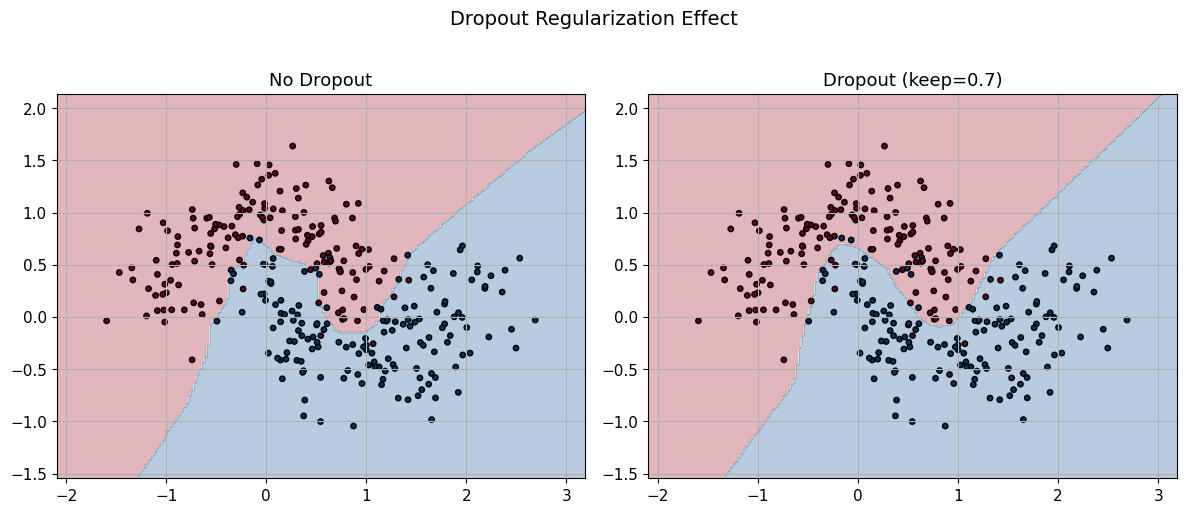

In [ ]:
def inverted_dropout_backward(dA, D, keep_prob):
    """Backprop through inverted dropout layer."""
    # (same shape as dA)
    return (dA * D) / keep_prob


class DropoutNetwork:
    """Fully-connected network with inverted dropout."""

    def __init__(self, layer_dims, keep_prob=0.8):
        self.keep_prob = keep_prob
        self.num_layers = len(layer_dims) - 1
        self.params = {}
        self.cache = {}

        for l in range(1, self.num_layers + 1):
            self.params[f"W{l}"] = np.random.randn(
                layer_dims[l], layer_dims[l - 1]
            ) * np.sqrt(2.0 / layer_dims[l - 1])
            self.params[f"b{l}"] = np.zeros((layer_dims[l], 1))

    def forward(self, X, training=True):
        # (input_dim, batch_num)
        A = X
        self.cache["A0"] = A

        for l in range(1, self.num_layers):
            W, b = self.params[f"W{l}"], self.params[f"b{l}"]
            # (hidden_dim, batch_num)
            Z = W @ A + b
            # (hidden_dim, batch_num)
            A = np.maximum(0, Z)

            # Apply dropout to hidden layers only
            A, D = inverted_dropout_forward(A, self.keep_prob, training=training)
            self.cache[f"Z{l}"], self.cache[f"A{l}"], self.cache[f"D{l}"] = Z, A, D

        # Output (no dropout on output layer)
        W, b = self.params[f"W{self.num_layers}"], self.params[f"b{self.num_layers}"]
        Z = W @ A + b
        A = 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))
        self.cache[f"Z{self.num_layers}"] = Z
        self.cache[f"A{self.num_layers}"] = A
        return A

    def backward(self, Y):
        grads = {}
        batch_num = Y.shape[1]
        # (output_dim, batch_num)
        dZ = self.cache[f"A{self.num_layers}"] - Y

        for l in range(self.num_layers, 0, -1):
            A_prev = self.cache[f"A{l - 1}"]
            grads[f"dW{l}"] = (1 / batch_num) * (dZ @ A_prev.T)
            grads[f"db{l}"] = (1 / batch_num) * np.sum(dZ, axis=1, keepdims=True)

            if l > 1:
                dA_prev = self.params[f"W{l}"].T @ dZ
                # Apply dropout mask in backward pass
                dA_prev = inverted_dropout_backward(
                    dA_prev, self.cache[f"D{l - 1}"], self.keep_prob
                )
                dZ = dA_prev * (self.cache[f"Z{l - 1}"] > 0).astype(float)

        return grads

    def train(self, X, Y, lr=0.01, epochs=5000, verbose=True):
        costs = []
        for epoch in range(epochs):
            A_last = self.forward(X, training=True)
            cost = -np.mean(
                Y * np.log(A_last + 1e-8) + (1 - Y) * np.log(1 - A_last + 1e-8)
            )
            grads = self.backward(Y)
            for l in range(1, self.num_layers + 1):
                self.params[f"W{l}"] -= lr * grads[f"dW{l}"]
                self.params[f"b{l}"] -= lr * grads[f"db{l}"]
            if epoch % 500 == 0:
                costs.append(cost)
                if verbose:
                    print(f"Epoch {epoch:5d} | Cost: {cost:.6f}")
        return costs


# Compare: no dropout vs dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, kp, title in zip(axes, [1.0, 0.7], ["No Dropout", "Dropout (keep=0.7)"]):
    np.random.seed(42)
    net = DropoutNetwork([2, 30, 20, 10, 1], keep_prob=kp)
    net.train(X_data, Y_data, lr=0.05, epochs=6000, verbose=False)
    # Inference mode — no dropout
    plot_decision_boundary_fn = lambda grid: net.forward(grid, training=False)

    x_min, x_max = X_data[0].min() - 0.5, X_data[0].max() + 0.5
    y_min, y_max = X_data[1].min() - 0.5, X_data[1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].T
    preds = net.forward(grid, training=False)
    preds_cls = (preds > 0.5).astype(int).reshape(xx.shape)

    ax.contourf(xx, yy, preds_cls, alpha=0.3, cmap="RdBu")
    ax.scatter(X_data[0], X_data[1], c=Y_data.ravel(), cmap="RdBu", edgecolors="k", s=15)
    ax.set_title(title)

plt.suptitle("Dropout Regularization Effect", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.2.3 Ensemble Interpretation

**Why Dropout ≈ Model Averaging**

With $n$ hidden units, each dropout mask defines a different "thinned" sub-network. There are $2^n$ possible masks, so dropout implicitly trains an exponential ensemble of sub-networks that **share weights**.

At test time, using the full network (no dropout) with scaled weights approximates the geometric mean of all sub-network predictions:

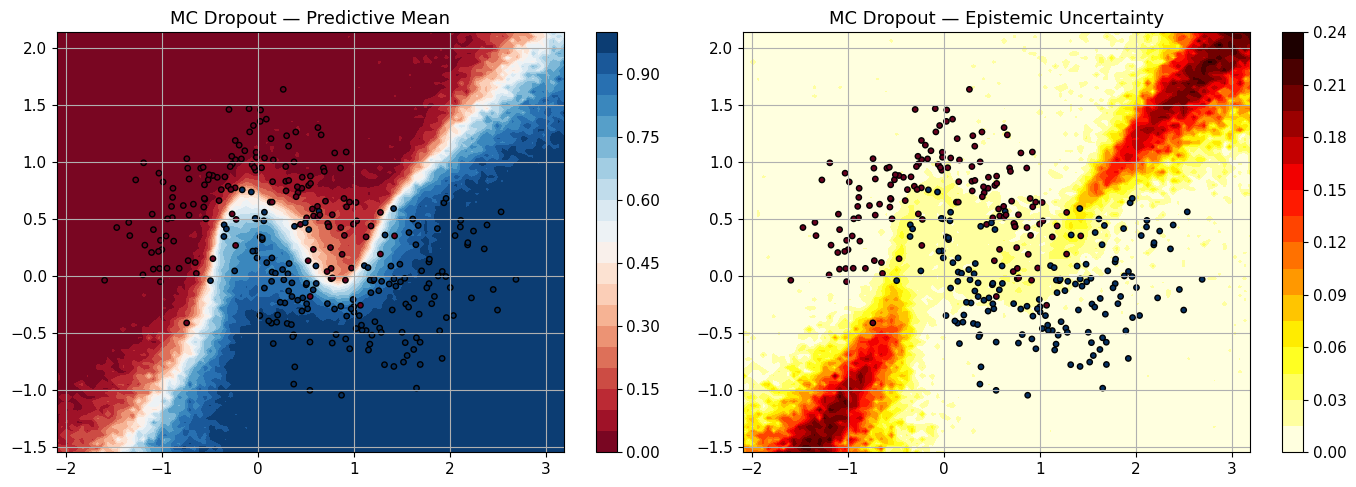

High uncertainty (bright) near the decision boundary and away from training data.


In [ ]:
# MC Dropout uncertainty estimation
np.random.seed(42)
mc_net = DropoutNetwork([2, 30, 20, 10, 1], keep_prob=0.7)
mc_net.train(X_data, Y_data, lr=0.05, epochs=6000, verbose=False)

x_min, x_max = X_data[0].min() - 0.5, X_data[0].max() + 0.5
y_min, y_max = X_data[1].min() - 0.5, X_data[1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
# (2, num_grid_points)
grid = np.c_[xx.ravel(), yy.ravel()].T

# Run T stochastic forward passes with dropout enabled
T = 50
# (T, 1, num_grid_points)
mc_preds = np.array([mc_net.forward(grid, training=True) for _ in range(T)])

# (1, num_grid_points)
pred_mean = mc_preds.mean(axis=0)
# (1, num_grid_points) — epistemic uncertainty
pred_var = mc_preds.var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predictive mean
im0 = axes[0].contourf(xx, yy, pred_mean.reshape(xx.shape), levels=20, cmap="RdBu")
axes[0].scatter(X_data[0], X_data[1], c=Y_data.ravel(), cmap="RdBu", edgecolors="k", s=15)
axes[0].set_title("MC Dropout — Predictive Mean")
plt.colorbar(im0, ax=axes[0])

# Epistemic uncertainty
im1 = axes[1].contourf(xx, yy, pred_var.reshape(xx.shape), levels=20, cmap="hot_r")
axes[1].scatter(X_data[0], X_data[1], c=Y_data.ravel(), cmap="RdBu", edgecolors="k", s=15)
axes[1].set_title("MC Dropout — Epistemic Uncertainty")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
print("High uncertainty (bright) near the decision boundary and away from training data.")

---
## 1.3 Data Augmentation as Implicit Regularization (Brief)

Data augmentation artificially inflates the training set by applying label-preserving transformations. It regularizes by:

1. **Increasing effective dataset size** — reducing variance  
2. **Encoding invariances** — the model learns features robust to the augmentations  
3. **Smoothing the loss landscape** — averaging over augmented copies is equivalent to adding a penalty on the gradient norm (Rajput et al., 2019)

Common augmentations:
- **Images**: random crop, flip, rotation, color jitter, cutout, mixup
- **Text**: synonym replacement, back-translation, token dropout
- **Tabular**: noise injection, SMOTE

We omit a full implementation here (it's domain-specific) but note that **augmentation is often the single most impactful regularizer** in practice.

---

## 1.4 Early Stopping

Monitor validation loss during training and stop when it begins to increase (the model starts overfitting).

Early stopping is equivalent to an L2 regularizer when the learning rate is small (Bishop, 1995; Sjöberg & Ljung, 1995). The number of training steps plays the role of the inverse regularization strength.

$$\text{Effective } \lambda \approx \frac{1}{\eta \cdot T}$$

where $\eta$ is the learning rate and $T$ is the number of steps.

Early stopping at epoch 1966. Best epoch: 1366


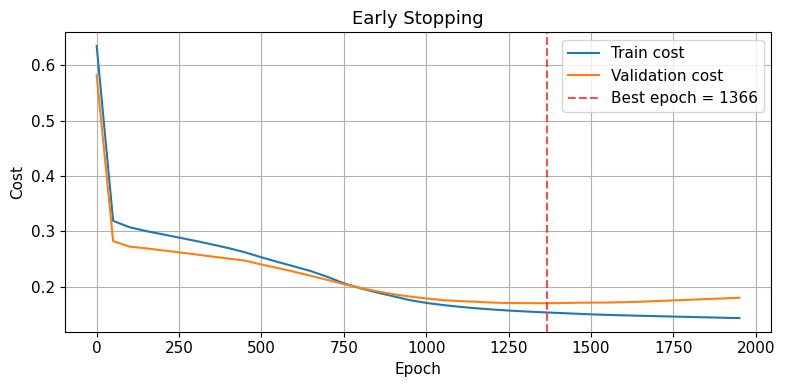

In [ ]:
def train_with_early_stopping(layer_dims, X_train, Y_train, X_val, Y_val,
                              lr=0.05, max_epochs=10000, patience=500):
    """Train network with early stopping on validation loss."""
    net = L2RegularizedNetwork(layer_dims, lambd=0.0)
    best_val_cost = np.inf
    best_epoch = 0
    train_costs, val_costs = [], []
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        A_train = net.forward(X_train)
        t_cost = net.compute_cost(A_train, Y_train)
        grads = net.backward(Y_train)
        net.update_params(grads, lr)

        A_val = net.forward(X_val)
        v_cost = -np.mean(
            Y_val * np.log(A_val + 1e-8) + (1 - Y_val) * np.log(1 - A_val + 1e-8)
        )

        if epoch % 50 == 0:
            train_costs.append(t_cost)
            val_costs.append(v_cost)

        if v_cost < best_val_cost:
            best_val_cost = v_cost
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    return train_costs, val_costs, best_epoch


# Split data into train/val
X_tr, X_vl, Y_tr, Y_vl = train_test_split(
    X_data.T, Y_data.T, test_size=0.3, random_state=42
)
X_tr, X_vl = X_tr.T, X_vl.T
Y_tr, Y_vl = Y_tr.T, Y_vl.T

np.random.seed(42)
t_costs, v_costs, best_ep = train_with_early_stopping(
    [2, 30, 20, 10, 1], X_tr, Y_tr, X_vl, Y_vl, lr=0.05, patience=600
)

fig, ax = plt.subplots(figsize=(8, 4))
epochs_axis = np.arange(len(t_costs)) * 50
ax.plot(epochs_axis, t_costs, label="Train cost")
ax.plot(epochs_axis, v_costs, label="Validation cost")
ax.axvline(best_ep, color="red", ls="--", alpha=0.7, label=f"Best epoch = {best_ep}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cost")
ax.set_title("Early Stopping")
ax.legend()
plt.tight_layout()
plt.show()